<a href="https://colab.research.google.com/github/Karuneshtiwari/ML-lab/blob/main/Lab07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

BASE_PATH = "/content/drive/MyDrive/ML_lab"
IMAGE_ROOT = os.path.join(BASE_PATH, "BreaKHis_v1")

CSV_PATH = os.path.join(
    BASE_PATH,
    "BreaKHis_metadata.csv"
)

SAMPLE_COUNT = 100
RESIZE_SHAPE = (16, 16)

SEED = 42
TEST_SIZE = 0.20

Mounted at /content/drive


In [ ]:
def locate_image(relative_name):

    relative_name = str(relative_name).replace("\\", "/")

    candidates = [
        os.path.join(BASE_PATH, relative_name),
        os.path.join(IMAGE_ROOT, relative_name)
    ]

    if relative_name.startswith("BreaKHis_v1/"):

        short_name = relative_name.split(
            "BreaKHis_v1/", 1
        )[1]

        candidates.append(
            os.path.join(
                IMAGE_ROOT,
                short_name
            )
        )

    for candidate in candidates:

        if os.path.isfile(candidate):
            return candidate

    return None


def get_target(path):

    path = str(path).lower()

    if "/benign/" in path:
        return "benign"

    if "/malignant/" in path:
        return "malignant"

    return None


def image_to_vector(
    path,
    size=(16, 16)
):

    image = Image.open(path).convert("L")

    image = image.resize(size)

    values = np.asarray(
        image,
        dtype=np.float32
    )

    return values.reshape(-1)


def create_image_features(
    metadata,
    per_class=100
):

    metadata = metadata.copy()

    metadata["target"] = metadata["filename"].map(
        get_target
    )

    metadata = metadata.dropna(
        subset=["target"]
    )

    selected_parts = []

    for target in [
        "benign",
        "malignant"
    ]:

        class_rows = metadata[
            metadata["target"] == target
        ]

        selected_parts.append(
            class_rows.sample(
                n=min(
                    per_class,
                    len(class_rows)
                ),
                random_state=SEED
            )
        )

    selected = pd.concat(
        selected_parts,
        ignore_index=True
    )

    features = []
    targets = []

    for _, record in selected.iterrows():

        image_path = locate_image(
            record["filename"]
        )

        if image_path is None:
            continue

        try:

            vector = image_to_vector(
                image_path,
                RESIZE_SHAPE
            )

            features.append(vector)
            targets.append(record["target"])

        except Exception:
            continue

    return (
        np.asarray(
            features,
            dtype=np.float32
        ),
        np.asarray(targets)
    )

In [ ]:
metadata = pd.read_csv(CSV_PATH)

X, y = create_image_features(
    metadata,
    SAMPLE_COUNT
)

print("Dataset Shape:", X.shape)

print("\nClass Distribution:")
print(pd.Series(y).value_counts())

Dataset Shape: (200, 256)

Class Distribution:
benign       100
malignant    100
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y
)

In [ ]:
#A1

def calculate_entropy(labels):

    class_counts = Counter(labels)
    total_samples = len(labels)

    entropy = 0.0

    for count in class_counts.values():

        probability = count / total_samples

        if probability > 0:
            entropy -= probability * math.log2(probability)

    return entropy

In [ ]:
#A2

def calculate_gini(labels):

    class_counts = Counter(labels)
    total_samples = len(labels)

    gini = 1.0

    for count in class_counts.values():

        probability = count / total_samples

        gini -= probability ** 2

    return gini

In [ ]:
#A3

def calculate_information_gain(X, labels, feature_index):

    total_entropy = calculate_entropy(labels)

    feature_values = X[:, feature_index]

    weighted_entropy = 0.0

    for value in np.unique(feature_values):

        subset_labels = labels[
            feature_values == value
        ]

        probability = len(subset_labels) / len(labels)

        weighted_entropy += (
            probability *
            calculate_entropy(subset_labels)
        )

    information_gain = (
        total_entropy -
        weighted_entropy
    )

    return information_gain


def find_root_node(X, labels):

    information_gains = {}

    for feature_index in range(X.shape[1]):

        information_gains[feature_index] = (
            calculate_information_gain(
                X,
                labels,
                feature_index
            )
        )

    root_node = max(
        information_gains,
        key=information_gains.get
    )

    return root_node, information_gains

In [ ]:
#A4

def bin_feature(
    feature,
    binning_type="equal_width",
    bins=4
):

    feature = np.asarray(feature)

    if bins <= 0:
        raise ValueError("Number of bins must be greater than 0")

    if binning_type == "equal_width":

        minimum = np.min(feature)
        maximum = np.max(feature)

        if minimum == maximum:
            return np.zeros(
                len(feature),
                dtype=int
            )

        edges = np.linspace(
            minimum,
            maximum,
            bins + 1
        )

        binned = np.digitize(
            feature,
            edges[1:-1]
        )

    elif binning_type == "frequency":

        ranks = pd.Series(feature).rank(
            method="first"
        )

        binned = pd.qcut(
            ranks,
            q=bins,
            labels=False,
            duplicates="drop"
        ).to_numpy()

    else:

        raise ValueError(
            "Use 'equal_width' or 'frequency'"
        )

    return binned

In [ ]:
#A5

def build_decision_tree(
    X,
    labels,
    feature_indices=None,
    depth=0,
    max_depth=5
):

    if len(np.unique(labels)) == 1:

        return {
            "type": "leaf",
            "class": labels[0]
        }

    if len(labels) == 0:

        return None

    if depth >= max_depth:

        majority_class = Counter(labels).most_common(1)[0][0]

        return {
            "type": "leaf",
            "class": majority_class
        }

    if feature_indices is None:

        feature_indices = list(
            range(X.shape[1])
        )

    best_feature = None
    best_gain = -1

    for feature_index in feature_indices:

        gain = calculate_information_gain(
            X,
            labels,
            feature_index
        )

        if gain > best_gain:

            best_gain = gain
            best_feature = feature_index

    if best_feature is None or best_gain <= 0:

        majority_class = Counter(labels).most_common(1)[0][0]

        return {
            "type": "leaf",
            "class": majority_class
        }

    node = {
        "type": "node",
        "feature": best_feature,
        "gain": best_gain,
        "branches": {}
    }

    feature_values = np.unique(
        X[:, best_feature]
    )

    remaining_features = [
        feature
        for feature in feature_indices
        if feature != best_feature
    ]

    for value in feature_values:

        mask = (
            X[:, best_feature] == value
        )

        subset_X = X[mask]
        subset_y = labels[mask]

        if len(subset_y) == 0:
            continue

        node["branches"][value] = build_decision_tree(
            subset_X,
            subset_y,
            remaining_features,
            depth + 1,
            max_depth
        )

    return node


def predict_tree(tree, sample):

    if tree["type"] == "leaf":

        return tree["class"]

    feature = tree["feature"]
    value = sample[feature]

    if value in tree["branches"]:

        return predict_tree(
            tree["branches"][value],
            sample
        )

    classes = []

    def collect_classes(node):

        if node["type"] == "leaf":
            classes.append(node["class"])
            return

        for branch in node["branches"].values():
            collect_classes(branch)

    collect_classes(tree)

    return Counter(classes).most_common(1)[0][0]


def predict_tree_dataset(tree, X):

    predictions = []

    for sample in X:

        predictions.append(
            predict_tree(
                tree,
                sample
            )
        )

    return np.array(predictions)

In [ ]:
#A6

def visualize_tree(tree, feature_names=None):

    if feature_names is None:
        feature_names = {
            i: f"Feature_{i}"
            for i in range(X.shape[1])
        }

    nodes = []
    edges = []

    def collect_nodes(node, node_id=0):

        if node["type"] == "leaf":

            nodes.append({
                "id": node_id,
                "label": f"Class: {node['class']}"
            })

            return node_id

        feature = node["feature"]
        gain = node["gain"]

        nodes.append({
            "id": node_id,
            "label": (
                f"{feature_names.get(feature, feature)}\n"
                f"IG = {gain:.4f}"
            )
        })

        next_id = node_id + 1

        for value, branch in node["branches"].items():

            child_id = next_id

            edges.append({
                "parent": node_id,
                "child": child_id,
                "label": f"Value = {value}"
            })

            used_id = collect_nodes(
                branch,
                child_id
            )

            next_id = used_id + 1

        return next_id - 1

    collect_nodes(tree)

    positions = {}

    def assign_positions(
        node,
        depth=0,
        x_start=0,
        x_end=1
    ):

        node_id = None

        for item in nodes:

            if item["id"] == len(positions):
                node_id = item["id"]
                break

        if node_id is None:
            return

        positions[node_id] = (
            (x_start + x_end) / 2,
            -depth
        )

    def layout(node, depth=0, x_start=0, x_end=1):

        node_id = len([
            p for p in positions
            if p is not None
        ])

        if node["type"] == "leaf":

            positions[node_id] = (
                (x_start + x_end) / 2,
                -depth
            )

            return node_id

        positions[node_id] = (
            (x_start + x_end) / 2,
            -depth
        )

        branches = list(
            node["branches"].items()
        )

        width = (
            (x_end - x_start) /
            max(len(branches), 1)
        )

        for index, (_, branch) in enumerate(branches):

            child_start = (
                x_start + index * width
            )

            child_end = child_start + width

            layout(
                branch,
                depth + 1,
                child_start,
                child_end
            )

        return node_id

    positions = {}

    def build_layout(
        node,
        node_id=0,
        depth=0,
        x_start=0,
        x_end=1
    ):

        positions[node_id] = (
            (x_start + x_end) / 2,
            -depth
        )

        if node["type"] == "leaf":
            return node_id + 1

        branches = list(
            node["branches"].items()
        )

        width = (
            (x_end - x_start) /
            max(len(branches), 1)
        )

        next_id = node_id + 1

        for index, (value, branch) in enumerate(branches):

            child_start = (
                x_start + index * width
            )

            child_end = child_start + width

            child_id = next_id

            edges.append({
                "parent": node_id,
                "child": child_id,
                "label": f"{value}"
            })

            next_id = build_layout(
                branch,
                child_id,
                depth + 1,
                child_start,
                child_end
            )

        return next_id

    positions = {}
    edges.clear()

    build_layout(tree)

    plt.figure(
        figsize=(18, 10)
    )

    for edge in edges:

        parent = edge["parent"]
        child = edge["child"]

        x1, y1 = positions[parent]
        x2, y2 = positions[child]

        plt.plot(
            [x1, x2],
            [y1, y2],
            linewidth=1
        )

        plt.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2,
            edge["label"],
            fontsize=8,
            ha="center"
        )

    for node_id, (x, y_pos) in positions.items():

        def find_node(current, target, current_id=0):

            if current_id == target:
                return current

            if current["type"] == "leaf":
                return None

            next_id = current_id + 1

            for branch in current["branches"].values():

                result = find_node(
                    branch,
                    target,
                    next_id
                )

                if result is not None:
                    return result

                next_id += count_nodes(branch)

            return None

        def count_nodes(node):

            if node["type"] == "leaf":
                return 1

            total = 1

            for branch in node["branches"].values():
                total += count_nodes(branch)

            return total

        current_node = find_node(
            tree,
            node_id
        )

        if current_node is None:
            continue

        if current_node["type"] == "leaf":

            label = (
                f"Class: "
                f"{current_node['class']}"
            )

        else:

            label = (
                f"Feature "
                f"{current_node['feature']}\n"
                f"IG = "
                f"{current_node['gain']:.4f}"
            )

        plt.text(
            x,
            y_pos,
            label,
            ha="center",
            va="center",
            bbox=dict(
                boxstyle="round,pad=0.5"
            )
        )

    plt.title(
        "Decision Tree Visualization"
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
#A7

def plot_decision_boundary(X, labels, feature_1=0, feature_2=1):

    selected_X = X[
        :,
        [feature_1, feature_2]
    ]

    binned_X = np.column_stack([
        bin_feature(
            selected_X[:, 0],
            "equal_width",
            4
        ),
        bin_feature(
            selected_X[:, 1],
            "equal_width",
            4
        )
    ])

    tree = build_decision_tree(
        binned_X,
        labels,
        max_depth=5
    )

    x_min = selected_X[:, 0].min()
    x_max = selected_X[:, 0].max()

    y_min = selected_X[:, 1].min()
    y_max = selected_X[:, 1].max()

    x_grid = np.linspace(
        x_min,
        x_max,
        200
    )

    y_grid = np.linspace(
        y_min,
        y_max,
        200
    )

    xx, yy = np.meshgrid(
        x_grid,
        y_grid
    )

    grid = np.column_stack([
        xx.ravel(),
        yy.ravel()
    ])

    grid_binned = np.column_stack([
        bin_feature(
            grid[:, 0],
            "equal_width",
            4
        ),
        bin_feature(
            grid[:, 1],
            "equal_width",
            4
        )
    ])

    predictions = predict_tree_dataset(
        tree,
        grid_binned
    )

    class_values = {
        label: index
        for index, label
        in enumerate(np.unique(labels))
    }

    Z = np.array([
        class_values[prediction]
        for prediction in predictions
    ])

    Z = Z.reshape(
        xx.shape
    )

    plt.figure(figsize=(8, 6))

    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.3
    )

    for label in np.unique(labels):

        mask = labels == label

        plt.scatter(
            selected_X[mask, 0],
            selected_X[mask, 1],
            label=label
        )

    plt.xlabel(
        f"Feature {feature_1}"
    )

    plt.ylabel(
        f"Feature {feature_2}"
    )

    plt.title(
        "Decision Tree Decision Boundary"
    )

    plt.legend()
    plt.show()

    return tree

In [ ]:
#A8

def tune_decision_tree(X, labels):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        labels,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=labels
    )

    classifier = DecisionTreeClassifier(
        random_state=SEED
    )

    parameter_grid = {
        "criterion": [
            "gini",
            "entropy"
        ],
        "max_depth": [
            3,
            5,
            7,
            None
        ],
        "min_samples_split": [
            2,
            5,
            10
        ],
        "min_samples_leaf": [
            1,
            2,
            4
        ]
    }

    grid_search = GridSearchCV(
        estimator=classifier,
        param_grid=parameter_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    grid_search.fit(
        X_train,
        y_train
    )

    best_model = grid_search.best_estimator_

    predictions = best_model.predict(
        X_test
    )

    test_accuracy = accuracy_score(
        y_test,
        predictions
    )

    return (
        grid_search,
        best_model,
        test_accuracy
    )

A1
Dataset Samples: 200
Class Distribution:
benign       100
malignant    100
Name: count, dtype: int64
Entropy: 1.0

A2
Gini Index: 0.5

A3
Root Node Feature: 157
Maximum Information Gain: 0.5809986547010986

A4
Binning Type: Equal Width
Number of Bins: 4

A5
Decision Tree Accuracy: 0.45

A6
Decision Tree Visualization:


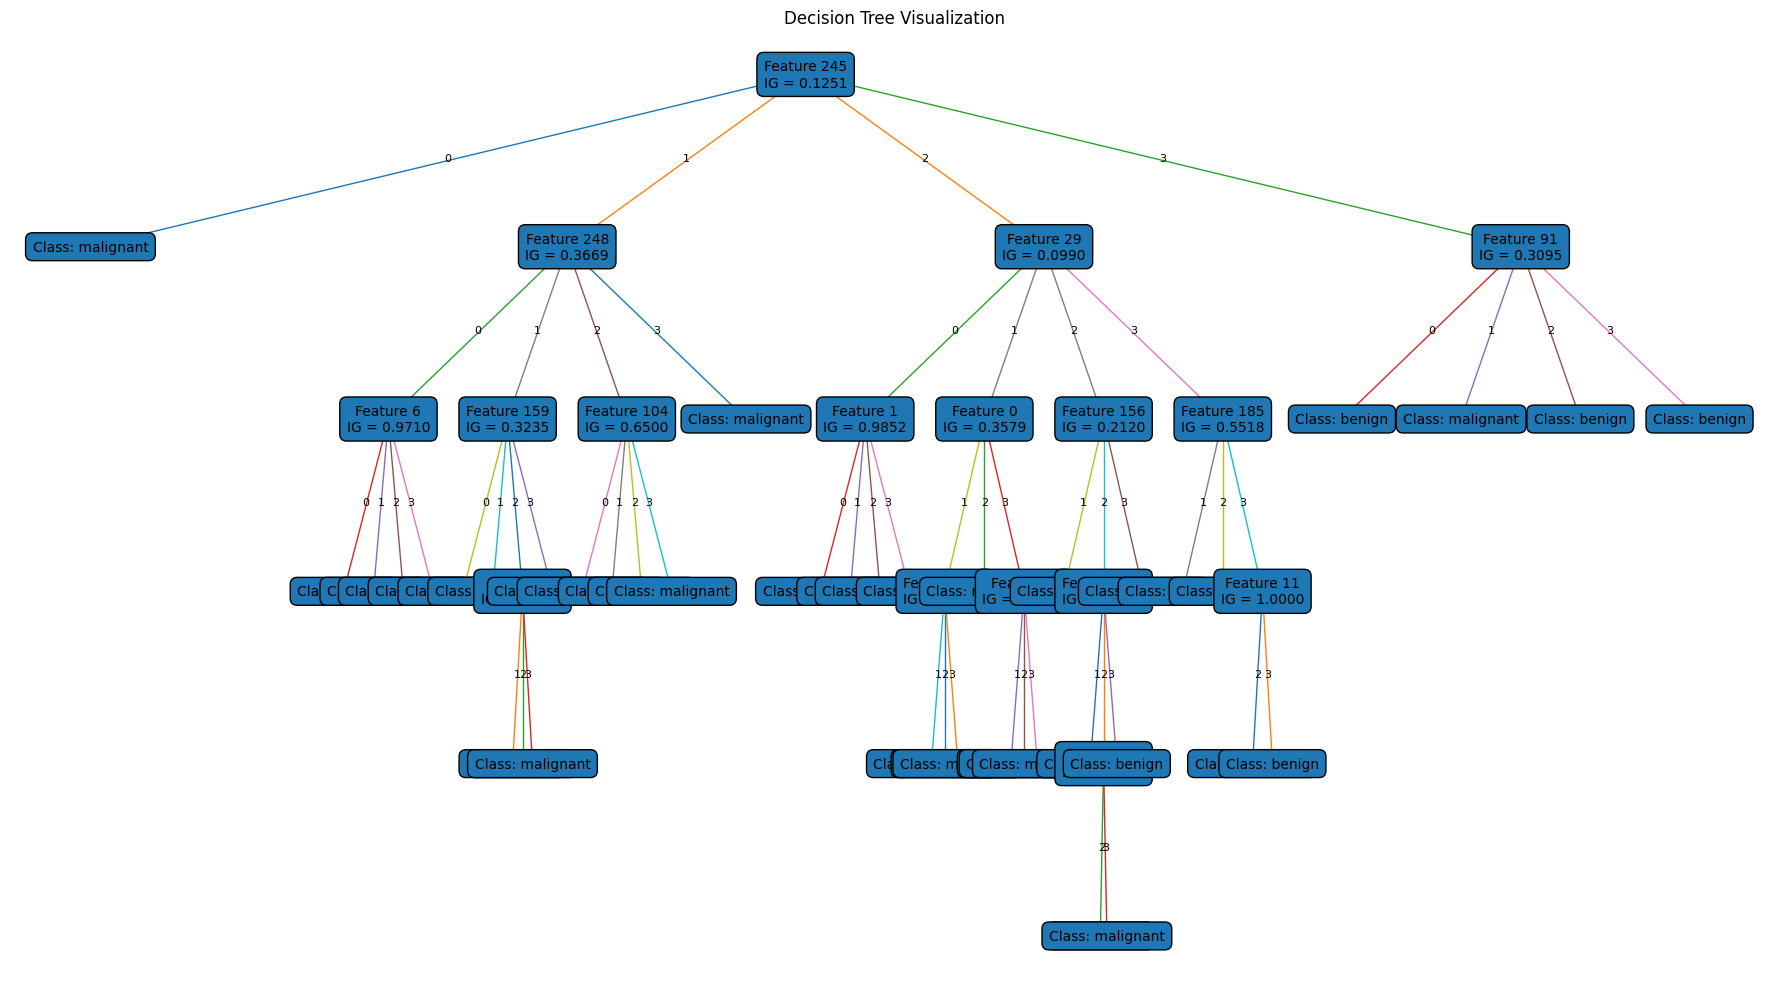


A7
Features Used: Feature 0 and Feature 1


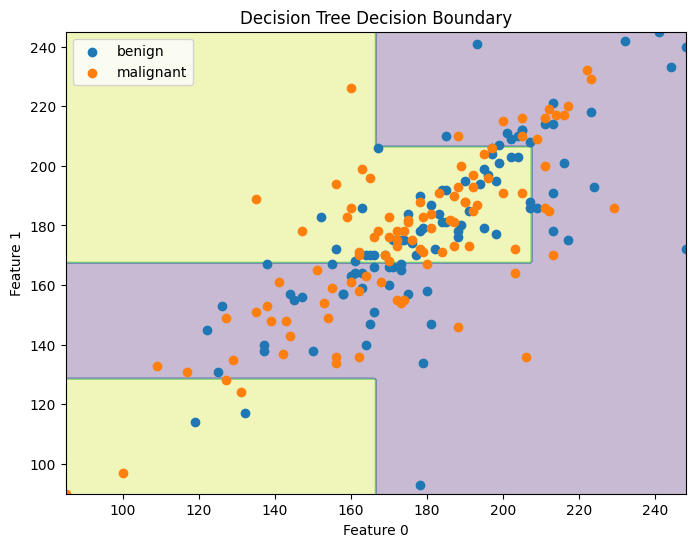


A8
Best Parameters:
{'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 5}

Best Cross-Validation Score:
0.55625

Test Accuracy with Tuned Model:
0.525


In [ ]:
#main

entropy_value = calculate_entropy(y)

gini_value = calculate_gini(y)

root_node, information_gains = find_root_node(
    X,
    y
)

binned_X = np.column_stack([
    bin_feature(
        X[:, i],
        "equal_width",
        4
    )
    for i in range(X.shape[1])
])

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    binned_X,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y
)

decision_tree = build_decision_tree(
    X_train_bin,
    y_train_bin,
    max_depth=5
)

predictions = predict_tree_dataset(
    decision_tree,
    X_test_bin
)

accuracy = np.mean(
    predictions == y_test_bin
)

grid_search, best_model, tuned_accuracy = tune_decision_tree(
    X,
    y
)

print("A1")
print("Dataset Samples:", len(y))
print("Class Distribution:")
print(pd.Series(y).value_counts())
print("Entropy:", entropy_value)

print("\nA2")
print("Gini Index:", gini_value)

print("\nA3")
print("Root Node Feature:", root_node)
print(
    "Maximum Information Gain:",
    information_gains[root_node]
)

print("\nA4")
print("Binning Type: Equal Width")
print("Number of Bins: 4")

print("\nA5")
print("Decision Tree Accuracy:", accuracy)

print("\nA6")
print("Decision Tree Visualization:")
visualize_tree(
    decision_tree
)

print("\nA7")
print("Features Used: Feature 0 and Feature 1")

plot_decision_boundary(
    X,
    y,
    feature_1=0,
    feature_2=1
)

print("\nA8")
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Score:")
print(grid_search.best_score_)

print("\nTest Accuracy with Tuned Model:")
print(tuned_accuracy)